# Read Counts

In [1]:
library(dplyr)
library(stringr)
library(tidyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Initial - QC

In [2]:
# raw and trimmed reads were written via script - found in 0QC_trimming-all
    # combining and pivoting to make easier to read

In [3]:
setwd('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/')
reads<-read.csv('reads.csv')
sampleids<-read.table('sampleids.txt', sep = "",header = FALSE)
sampleids$sampleid <- sampleids$V1
sampleids$V1 <- NULL

In [4]:
# make sure raw read counts R1 and R2 match
raw_read_match<-reads %>%
    filter(step == 'raw') %>%
    # add base sampleid to match by
    mutate(sampleid = str_remove(sample, "_R[12]_001.fastq")) %>%
    group_by(sampleid) %>%
    # make sure there are 2 seqs per sameplid and that there is only 1 distinct value (meaning they have the same read count)
    mutate(reads_match = case_when(
      n() == 2 & n_distinct(read_count) == 1 ~ TRUE,
      TRUE ~ FALSE
  )) %>%
  ungroup()

# make sure there are no falses
raw_read_match %>%
    filter(reads_match == FALSE)

# perfect they all match 

sample,read_count,step,sampleid,reads_match
<chr>,<int>,<chr>,<chr>,<lgl>


In [5]:
# check sample numbers match 
nsample<-nrow(sampleids) # 225 samples
nsample*2

nrow(reads%>%filter(step=='raw'))
# extra sample is "Undetermined"

[1] 450

[1] 452

In [6]:
# filter for just one Read per sample
raw_reads <-raw_read_match %>%
    group_by(sampleid, read_count) %>%
    slice_head(n=1) %>%
    ungroup() %>%
    select(-sample,-reads_match)
nrow(raw_reads)

[1] 226

In [7]:
# separate trimmed step 
trimmed<-reads %>%
    filter(step == 'trimmed') %>%
    # add base ID 
    mutate(sampleid = str_remove(sample, "_R[1]_001")) %>%
    select(-sample)
# and add raw back in 
reads_all<-rbind(raw_reads,trimmed)

In [8]:
# then pivot
reads_wide<-reads_all%>%
    pivot_wider(names_from = step,
                values_from = read_count)
print(reads_wide)

# A tibble: 226 × 3
   sampleid                        raw   trimmed
   <chr>                         <int>     <int>
 1 052022_BEL_CBC_T1_10_PSTR  68572842  68449647
 2 052022_BEL_CBC_T1_11_PSTR  48741905  48660782
 3 052022_BEL_CBC_T1_12_MCAV 166267321 165624856
 4 052022_BEL_CBC_T1_13_MCAV  86263796  86076666
 5 052022_BEL_CBC_T1_1_PAST   85047990  84808864
 6 052022_BEL_CBC_T1_34_PAST  31359387  31274591
 7 052022_BEL_CBC_T1_35_OANN  55101910  55033169
 8 052022_BEL_CBC_T1_39_MCAV  83479374  83235507
 9 052022_BEL_CBC_T1_40_MCAV  68897750  68586963
10 052022_BEL_CBC_T1_41_OANN  40011606  39927902
# ℹ 216 more rows


In [9]:
head(reads_all)
head(reads_wide)

read_count,step,sampleid
<int>,<chr>,<chr>
68572842,raw,052022_BEL_CBC_T1_10_PSTR
48741905,raw,052022_BEL_CBC_T1_11_PSTR
166267321,raw,052022_BEL_CBC_T1_12_MCAV
86263796,raw,052022_BEL_CBC_T1_13_MCAV
85047990,raw,052022_BEL_CBC_T1_1_PAST
31359387,raw,052022_BEL_CBC_T1_34_PAST


sampleid,raw,trimmed
<chr>,<int>,<int>
052022_BEL_CBC_T1_10_PSTR,68572842,68449647
052022_BEL_CBC_T1_11_PSTR,48741905,48660782
052022_BEL_CBC_T1_12_MCAV,166267321,165624856
052022_BEL_CBC_T1_13_MCAV,86263796,86076666
052022_BEL_CBC_T1_1_PAST,85047990,84808864
052022_BEL_CBC_T1_34_PAST,31359387,31274591


In [10]:
# change incorrect sample id (wrong specie)
reads_wide<-reads_wide %>%
    mutate(sampleid = if_else(sampleid=='052022_BEL_CBC_T1_63_OFAV','052022_BEL_CBC_T1_63_OANN',sampleid))
reads_all<-reads_all %>%
    mutate(sampleid = if_else(sampleid=='052022_BEL_CBC_T1_63_OFAV','052022_BEL_CBC_T1_63_OANN',sampleid))

In [11]:
# rewrite long and wide format

In [12]:
# reorder columns 
reads_all <- reads_all[, c('sampleid','read_count','step')]

In [13]:
# write.csv(reads_all,'reads_filtered.txt', row.names = FALSE, quote = FALSE)
# write.table(reads_wide,'reads_wide.txt', sep = "\t",row.names = FALSE, quote = FALSE)

In [14]:
# percentage lost in trimming step?
reads_wide<-reads_wide %>%
    mutate(pct_yield = round((trimmed / raw) * 100,2))
reads_wide %>% arrange(pct_yield)

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
7_3_Neg,6030707,5925379,98.25
7_11_Neg,21262507,21046368,98.98
052022_BEL_CBC_T2_60_PAST,104718356,103807571,99.13
052022_BEL_CBC_T1_52_PAST,94884365,94301477,99.39
052022_BEL_CBC_T1_61_PAST,74286118,73869279,99.44
062019_BEL_CBC_T2_2_PAST,28081060,27923531,99.44
122022_BEL_CBC_T1_150_PAST,33672160,33493920,99.47
052022_BEL_CBC_T2_10_MCAV,86868928,86447447,99.51
052022_BEL_CBC_T3_40_MCAV,87769648,87360332,99.53


In [15]:
# sort into groups 
# read in metadata 
colony<-read.csv('CBC_ColonyData.csv')
sampledata<- read.csv('CBC_samples.csv')

In [16]:
sampledata_copy<-sampledata
sampledata<-sampledata %>%
    filter(Tubelabel_species %in% sampleids$sample) %>%
    filter(!(Sample_type %in% c('TEM','Probiotics','Syringe'))) %>%
    mutate(colony_id = paste0("T",TransectNum,"_",NewTagNum,"_",Species)) %>%
    select(-Country, -Location, -OldTagNum, -Time_sampled, -Time_processed, -Sample_type, -Sample_physical_location, -Extraction_physical_location, -Notes, -Date_sequenced) %>%
    rename(sampleid = Tubelabel_species)

In [17]:
# add to seq data 
reads_combined<-reads_wide %>% 
    left_join(sampledata, by = 'sampleid')

In [18]:
options(repr.plot.height = 8, repr.plot.width = 10)

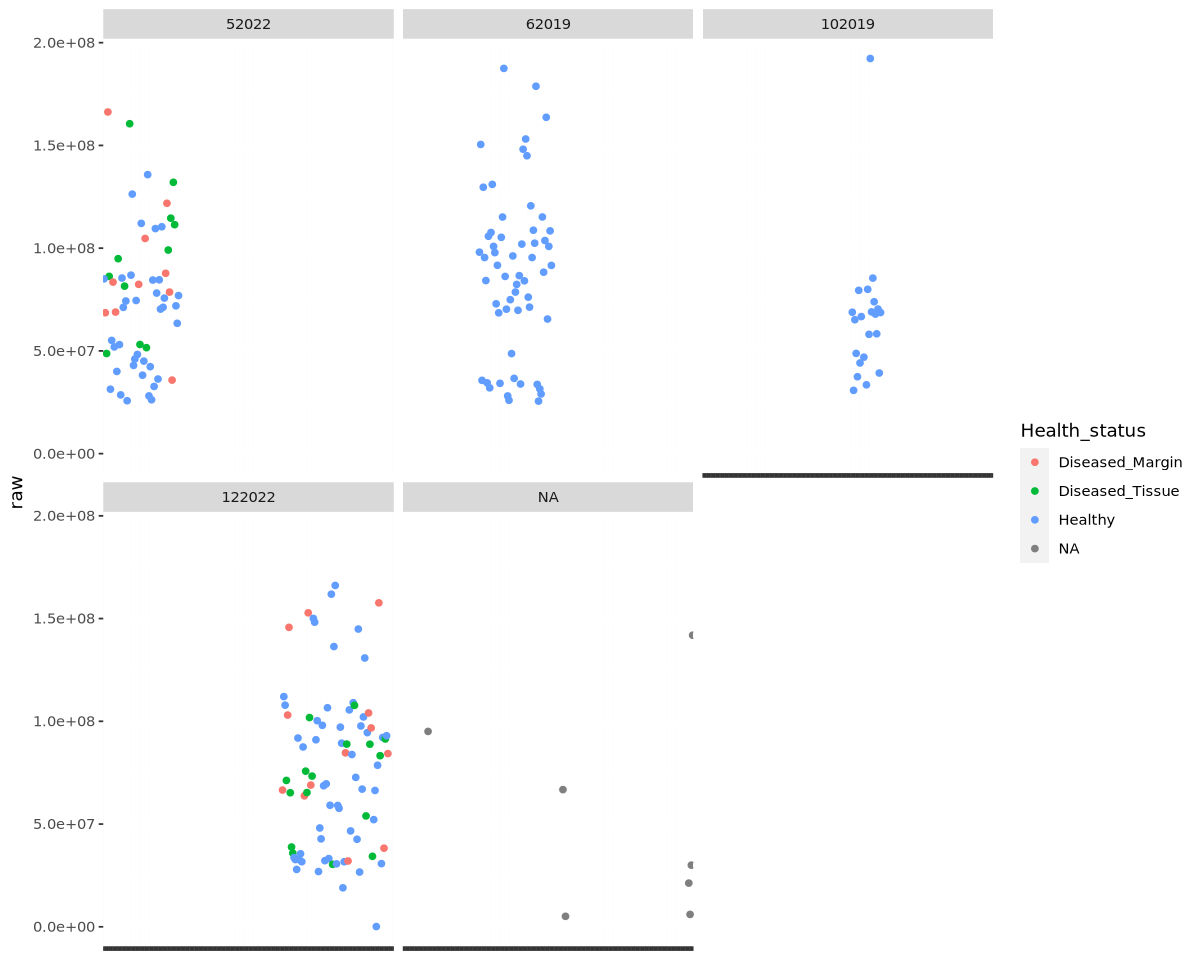

In [19]:
# view num of reads per sample - identify outliers 
ggplot(reads_combined, aes(x=sampleid, y = raw, color = Health_status))+
    geom_point()+
    facet_wrap(~Month_year)+
    theme(axis.title.x=element_blank(),
        axis.text.x=element_blank())

In [20]:
# pretty even spread across time points
# lets look at seqs with rly low reads 

In [21]:
head(reads_wide %>% arrange(raw),20)
# definitely not good that some of these are lower than the negatives 
# can look more at these after next step? not sure what to do yet 
# will probably have to get rid of the 120222_t4_3_mcav since it is lowest 

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA
7_3_Neg,6030707,5925379,98.25
122022_BEL_CBC_T3_127_OFAV,18979588,18941021,99.80
7_11_Neg,21262507,21046368,98.98
062019_BEL_CBC_T3_24_PAST,25554334,25506424,99.81
052022_BEL_CBC_T1_62_MCAV,25748617,25677123,99.72
062019_BEL_CBC_T2_20_PAST,25959288,25903510,99.79
052022_BEL_CBC_T2_72_OFAV,26234287,26188996,99.83


In [22]:
# how can i find like samples with the lowest 10% of read coverage 
summary(reads_wide)

   sampleid              raw               trimmed            pct_yield    
 Length:226         Min.   :   120943   Min.   :   120525   Min.   :98.25  
 Class :character   1st Qu.: 45291641   1st Qu.: 45459415   1st Qu.:99.72  
 Mode  :character   Median : 74727471   Median : 74764042   Median :99.78  
                    Mean   : 77443169   Mean   : 77335407   Mean   :99.75  
                    3rd Qu.: 99991119   3rd Qu.: 99357026   3rd Qu.:99.83  
                    Max.   :192301811   Max.   :191938002   Max.   :99.88  
                                        NA's   :3           NA's   :3      

In [23]:
# maybe look at everything lower than the first quartile?
reads_wide %>%
    filter(raw < 45291641) %>% 
    arrange(raw)
# 57 samples lower than first quartile

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA
7_3_Neg,6030707,5925379,98.25
122022_BEL_CBC_T3_127_OFAV,18979588,18941021,99.80
7_11_Neg,21262507,21046368,98.98
062019_BEL_CBC_T3_24_PAST,25554334,25506424,99.81
052022_BEL_CBC_T1_62_MCAV,25748617,25677123,99.72
062019_BEL_CBC_T2_20_PAST,25959288,25903510,99.79
052022_BEL_CBC_T2_72_OFAV,26234287,26188996,99.83


In [24]:
low <- quantile(reads_wide$raw, probs = 0.10)

low_samples <- reads_wide %>%
  filter(raw < low) %>%
  arrange(raw)

low_samples

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA
7_3_Neg,6030707,5925379,98.25
122022_BEL_CBC_T3_127_OFAV,18979588,18941021,99.80
7_11_Neg,21262507,21046368,98.98
062019_BEL_CBC_T3_24_PAST,25554334,25506424,99.81
052022_BEL_CBC_T1_62_MCAV,25748617,25677123,99.72
062019_BEL_CBC_T2_20_PAST,25959288,25903510,99.79
052022_BEL_CBC_T2_72_OFAV,26234287,26188996,99.83


In [25]:
# set thresholds - see how many samples fall into each?
# need to read to determine what the thresholds should be 
reads_wide <- reads_wide %>%
  mutate(qc_status = case_when(
      raw < 1e6 ~ "Fail (<1M)",
      raw < 1e7 ~ "Low (1M-10M)",
      TRUE ~ "Pass (>10M)"
  ))

In [26]:
reads_wide %>%
    group_by(qc_status) %>%
    summarise(n = n())

qc_status,n
<chr>,<int>
Fail (<1M),1
Low (1M-10M),2
Pass (>10M),223


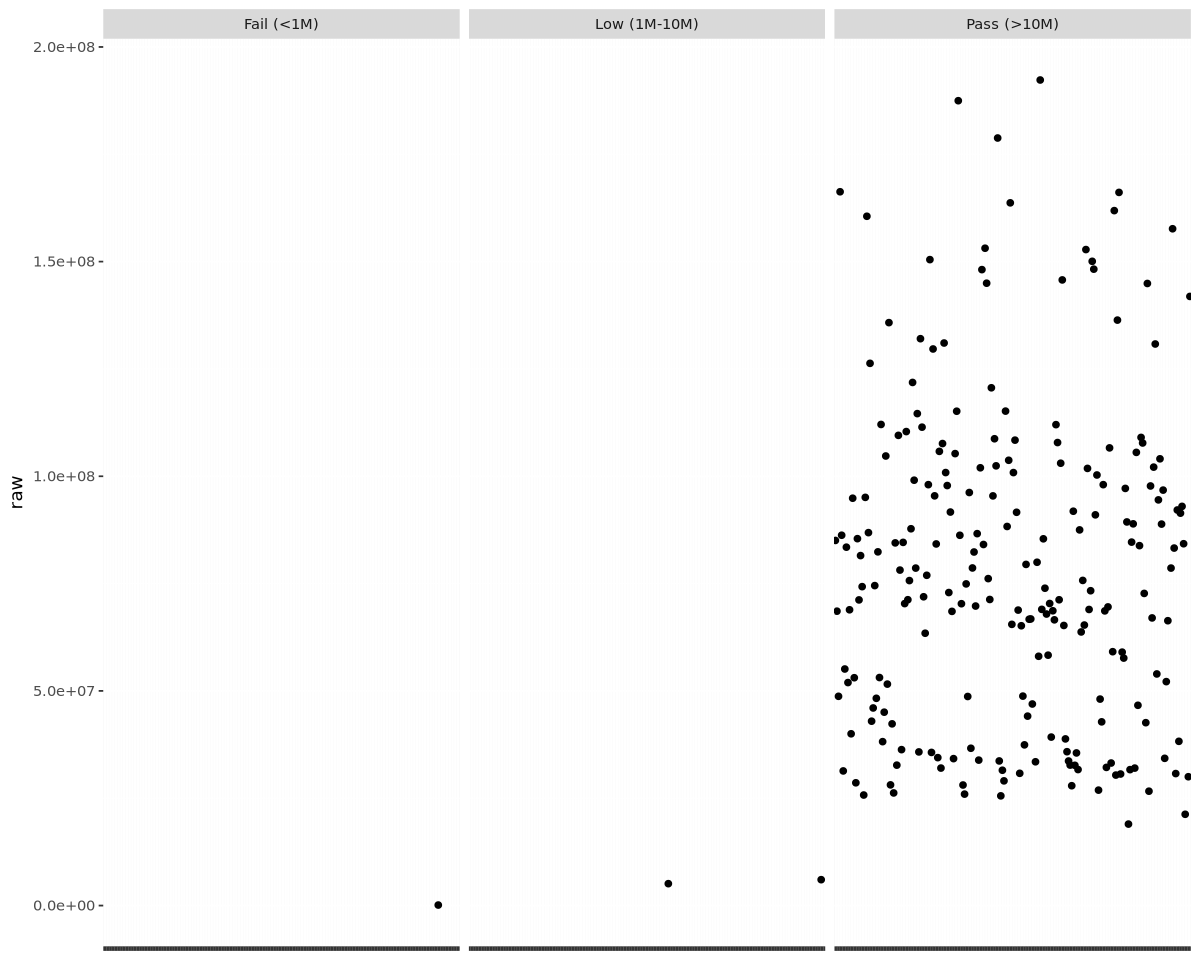

In [27]:
# view num of reads per sample - identify outliers 
ggplot(reads_wide, aes(x=sampleid, y = raw))+
    geom_point()+
    facet_wrap(~qc_status)+
    theme(axis.title.x=element_blank(),
        axis.text.x=element_blank())

In [28]:
reads_wide %>%
    filter(!(qc_status == "Pass (>10M)"))

sampleid,raw,trimmed,pct_yield,qc_status
<chr>,<int>,<int>,<dbl>,<chr>
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA,Low (1M-10M)
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65,Fail (<1M)
7_3_Neg,6030707,5925379,98.25,Low (1M-10M)


In [29]:
# can deffs filter these out for now and then decide about the rest??
# just filtering out hosts and this 1 sample, going to assemble negatives together

In [30]:
reads_filtered<-reads_wide$sampleid[names(reads_wide$sampleid) %in% c('102019_BEL_CBC_T2_31_PSTR_host','102019_BEL_CBC_T2_30_PSTR_host','122022_BEL_CBC_T4_3_MCAV')]

In [31]:
filtered_samples<-reads_wide$sampleid[!(reads_wide$sampleid %in% c('102019_BEL_CBC_T2_31_PSTR_host','102019_BEL_CBC_T2_30_PSTR_host',
                                                 '122022_BEL_CBC_T4_3_MCAV',"Undetermined"))]

In [32]:
# idk why cant fix oann rn so going to add data manually for now 
samplefix<-data.frame('sampleid' = '052022_BEL_CBC_T1_63_OANN','Month_year' = 52022, 'Transect' = 'CBC30N', 'TransectNum' = 1, 'NewTagNum' = '25', 
           'Species' = 'OANN', 'SampleNum' = '63', 'Health_status' = 'Healthy', 'colony_id' = 'T1_25_OANN')
reads_combined<-reads_combined %>%
    rows_update(samplefix, by = "sampleid")

In [33]:
reads_combined<-reads_combined %>%
# add metadata for negatives
    mutate(group = if_else(grepl("Neg",sampleid), "Negative", paste0(Month_year, "_", Species, "_", Health_status))) %>%
# and combine orbis
    mutate(Species = case_when(grepl("Neg",sampleid) ~"NEG",
                               Species == "OFAV" ~ "ORBI",
                               Species == "OANN" ~ "ORBI",
                               TRUE ~ Species))

In [34]:
# investigate NAs 
reads_combined %>%
    filter(grepl("NA",group))

sampleid,raw,trimmed,pct_yield,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,Sampling_notes,colony_id,group
<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
102019_BEL_CBC_T2_30_PSTR_host,66763853,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA_NA_NA
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA_NA_NA
Undetermined,141888465,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA_NA_NA


In [35]:
# this is supposed to be an oann : 052022_BEL_CBC_T1_63_OFAV - will change sample name and everything from here but leaving raw files alone 
# 122022_BEL_CBC_T4_1_OFAV was misnumbered as #4 (found raw datasheet and corrected in sctld_samples)
# 122022_BEL_CBC_T4_8_PSTR was misnumbered as #3 (found raw datasheet and corrected in sctld_samples)

# reuploading metadata to fix these

In [36]:
unique(reads_combined$group)

[1] "52022_PSTR_Diseased_Margin"  "52022_PSTR_Diseased_Tissue" 
 [3] "52022_MCAV_Diseased_Margin"  "52022_MCAV_Diseased_Tissue" 
 [5] "52022_PAST_Healthy"          "52022_OANN_Healthy"         
 [7] "52022_PSTR_Healthy"          "52022_PAST_Diseased_Tissue" 
 [9] "52022_MCAV_Healthy"          "52022_OFAV_Healthy"         
[11] "52022_PAST_Diseased_Margin"  "62019_MMEA_Healthy"         
[13] "62019_PAST_Healthy"          "62019_MCAV_Healthy"         
[15] "102019_PSTR_Healthy"         "NA_NA_NA"                   
[17] "122022_OANN_Diseased_Margin" "122022_PSTR_Healthy"        
[19] "122022_OANN_Healthy"         "122022_PSTR_Diseased_Tissue"
[21] "122022_PSTR_Diseased_Margin" "122022_PAST_Diseased_Margin"
[23] "122022_OANN_Diseased_Tissue" "122022_PAST_Diseased_Tissue"
[25] "122022_MCAV_Diseased_Tissue" "122022_PAST_Healthy"        
[27] "122022_MCAV_Healthy"         "122022_OFAV_Diseased_Margin"
[29] "122022_OFAV_Diseased_Tissue" "122022_OFAV_Healthy"        
[31] "122022_MCAV_Diseased_Margin" "Negative"

In [37]:
# filter out unusable samples in reads_combined
reads_combined<-reads_combined %>% filter(sampleid %in% filtered_samples) %>% select (-Sampling_notes)

In [38]:
# add group and spp to filtered sample list 
head(filtered_samples)
filtered_sample_group<-reads_combined %>%
    select(sampleid,Species,group) %>%
    rename(specie = Species)
tail(filtered_sample_group)

[1] "052022_BEL_CBC_T1_10_PSTR" "052022_BEL_CBC_T1_11_PSTR"
[3] "052022_BEL_CBC_T1_12_MCAV" "052022_BEL_CBC_T1_13_MCAV"
[5] "052022_BEL_CBC_T1_1_PAST"  "052022_BEL_CBC_T1_34_PAST"

sampleid,specie,group
<chr>,<chr>,<chr>
122022_BEL_CBC_T4_6_MCAV,MCAV,122022_MCAV_Diseased_Tissue
122022_BEL_CBC_T4_8_PSTR,PSTR,122022_PSTR_Healthy
122022_BEL_CBC_T4_9_OFAV,ORBI,122022_OFAV_Diseased_Margin
7_11_Neg,NEG,Negative
7_3_Neg,NEG,Negative
Negative_extract_11-2-24,NEG,Negative


In [39]:
# write.table(filtered_sample_group, 'filtered_sample_groups.txt', row.names = FALSE, quote = FALSE, sep = '\t')
write.csv(reads_combined, "reads_meta.csv", row.names = FALSE, quote = FALSE)

In [168]:
# need to create appendix for all of these freakin files i created

# filtered_sample_group.txt (filtered_sample_groups) = filtered sample list with spp and group
# filtered_samples.txt = filtered sample list 
# reads.csv = raw calculated reads from all samples: raw and trimmed steps
# reads_filtered = same as above but kept only one F/R read per sample
# reads_meta.csv (reads_combined) = read counts raw and trimmed with metadata, filtered samples



## Assembly Steps

### Multiqc in bash

In [ ]:
#!/bin/bash
#SBATCH -c 24  # Number of Cores per Task
#SBATCH --mem=50G  # Requested Memory
#SBATCH -p cpu  # Partition
#SBATCH -t 48:00:00  # Job time limit
#SBATCH --mail-type=ALL
#SBATCH -o /work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs/slurm-multiqc-%j.out  # %j = job ID

# run multiqc in both host removal and symbiont steps to calculate read count..
# get unique species from list of samples, spp, and groups

module load conda/latest
conda activate qc

slurm_dir="/work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs"
base_dir="/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw"
cd $base_dir

dir_list=$(ls -d */)
for dir in $dir_list; do 
    spp=${dir%/}
    echo "fastqc host_removed spp: ${spp}"
    fastqc ${spp}/assembly/host_removed/*.fastq* --threads 16
    echo "fastqc final_filtered spp: ${spp}"
    fastqc ${spp}/assembly/final_filtered/*_ready.fastq* --threads 16

    echo "multiqc spp: ${spp}"
    multiqc $base_dir/$spp/. $slurm_dir/$spp/. \
            -n "${spp}_QC_Report" \
            --outdir "${base_dir}/${spp}/assembly/qc_reports"
done

conda deactivate

# job id: 56139675, 56233305

In [ ]:
#!/bin/bash
#SBATCH -c 1  # Number of Cores per Task
#SBATCH --mem=50G  # Requested Memory
#SBATCH -p cpu  # Partition
#SBATCH -t 24:00:00  # Job time limit
#SBATCH --mail-type=ALL
#SBATCH -o /work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs/slurm-multiqc-%j.out
# get the past and pstr redoes

module load conda/latest
conda activate qc

slurm_dir="/work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs"
base_dir="/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw"
cd $base_dir

spp="PAST"
echo "fastqc host_removed spp: ${spp}"
fastqc ${spp}/assembly/host_removed_past/*.fastq* --threads 4
echo "fastqc final_filtered spp: ${spp}"
fastqc ${spp}/assembly/final_filtered2/*_ready.fastq* --threads 4

echo "multiqc spp: ${spp}"
multiqc $base_dir/$spp/. $slurm_dir/$spp/. \
        -d \
        -n "${spp}_QC_Report" \
        --outdir "${base_dir}/${spp}/assembly/qc_reports"

spp="PSTR"
echo "fastqc final_filtered spp: ${spp}"
fastqc ${spp}/assembly2/final_filtered2/*_ready.fastq* --threads 4
echo "multiqc spp: ${spp}"
multiqc $base_dir/$spp/ $slurm_dir/$spp/ \
        -d \
        -n "${spp}_QC_Report" \
        --outdir "${base_dir}/${spp}/assembly2/qc_reports"

conda deactivate
# job ID 61323917

In [ ]:
# manually ran 1 sample cuz for some reason fastqc skipped it


### Read count review - python
file flow path:\
trimmed (${id}_R1_001_val_1.fq)\
-> host removed (host_removed_R1.fastq)\
-> symbiont, human fastqc (_host_removed_R1.tagged_filter.fastq.gz)\
-> repair (_host_removed_R1.tagged_filter_ready.fastq.gz)

In [1]:
import os
import gzip
# from Bio import SeqIO
import pandas as pd
import re
import numpy as np
from pathlib import Path

In [2]:
# set dir
os.chdir('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/')

In [3]:
# upload all multiqc reports and compile

In [4]:
# repeat for genome alignments - symbiont, human
pattern = "*/assembly/qc_reports/*_QC_Report_data/multiqc_fastq_screen.txt"
files = list(Path('.').glob(pattern))
# change NEG path so it includes all neg samples
files[3] = Path("NEG/assembly/sym_human_removed/multiqc_data/multiqc_fastq_screen.txt")
# update PSTR path - reran multiqc with updated single file error
files[1] = Path("PSTR/assembly/qc_reports/multiqc_data_redo/multiqc_fastq_screen.txt")

df_list = [pd.read_csv(f, sep='\t') for f in files]
multiqc_df = pd.concat(df_list, ignore_index=True)

In [5]:
files

[PosixPath('ORBI/assembly/qc_reports/ORBI_QC_Report_data/multiqc_fastq_screen.txt'),
 PosixPath('PSTR/assembly/qc_reports/multiqc_data_redo/multiqc_fastq_screen.txt'),
 PosixPath('PAST/assembly/qc_reports/PAST_QC_Report_data/multiqc_fastq_screen.txt'),
 PosixPath('NEG/assembly/sym_human_removed/multiqc_data/multiqc_fastq_screen.txt'),
 PosixPath('MCAV/assembly/qc_reports/MCAV_QC_Report_data/multiqc_fastq_screen.txt'),
 PosixPath('MMEA/assembly/qc_reports/MMEA_QC_Report_data/multiqc_fastq_screen.txt')]

In [6]:
multiqc_df.shape

(550, 28)

In [7]:
# id samples that has the file paths
has_path = multiqc_df['Sample'].str.contains(r' \| ', regex=True)

# Extract the file path (if present) into a new column
multiqc_df['File_Path'] = multiqc_df['Sample'].str.rsplit(' | ', n=1).str[0].where(has_path, np.nan)

# Update the 'Sample' column to only contain the clean sample ID
multiqc_df['Sample'] = multiqc_df['Sample'].str.rsplit(' | ', n=1).str[-1]

In [8]:
multiqc_df['File_Path'].unique()

array([nan,
       'scratch4 | workspace | brooke_sienkiewicz_student_uml_edu-bel_raw | PAST | . | assembly | sym_human_removed',
       'scratch4 | workspace | brooke_sienkiewicz_student_uml_edu-bel_raw | PAST | . | assembly | sym_human_removed2'],
      dtype=object)

In [9]:
# past - 
# only keep sym human 2 path (this is after aligning to the PAST genome) (the other is from aligning to SSID)
multiqc_df = multiqc_df.loc[multiqc_df['File_Path'] != 'scratch4 | workspace | brooke_sienkiewicz_student_uml_edu-bel_raw | PAST | . | assembly | sym_human_removed',]

# only keep pstr assembly2
# multiqc_df = multiqc_df.loc[multiqc_df['File_Path'] != 'scratch4 | workspace | brooke_sienkiewicz_student_uml_edu-bel_raw | PSTR | assembly | sym_human_removed',]

In [10]:
multiqc_df.head()
multiqc_df.shape

(444, 29)

In [11]:
multiqc_df.drop(columns='File_Path',inplace=True)

In [12]:
# fix pstr and past sample ids

# multiqc_df['filepath']=multiqc_df['Sample'].str.extract('scratch4 | workspace | brooke_sienkiewicz_student_uml_edu-bel_raw | PSTR | assembly2 | sym_human_removed | ')
# multiqc_df['filepath']=multiqc_df['Sample'].str.extract('scratch4 | workspace | brooke_sienkiewicz_student_uml_edu-bel_raw | PAST | . | assembly | sym_human_removed2 | ')
# multiqc_df['filepath']=multiqc_df['Sample'].str.extract('scratch4 | workspace | brooke_sienkiewicz_student_uml_edu-bel_raw | PAST | . | assembly | sym_human_removed | ')

In [13]:
# multiqc_df['Sample'].unique()

In [14]:
# remove exact duplicate rows 
# multiqc_clean=multiqc_df.drop_duplicates()

In [15]:
# multiqc_df['File_Path']=multiqc_df['File_Path'].str.replace('scratch4 | workspace | brooke_sienkiewicz_student_uml_edu-bel_raw | ','')

#### Host removal and repair step
- (I know these steps are out of order but they're both in 1 file)
- fastqc multiqc results -> extract "Sequences" from each "host_removed" file
- comparing to trimmed will get you alignment %
    - (can also look at slurm output but bc I ran so many times I think this will be easiest for now) 

In [16]:
# upload all qc results
    # i think this has pre and post host removal - so can subtract to get read matches??
pattern = "*/assembly/qc_reports/*_QC_Report_data/multiqc_fastqc.txt"
files = list(Path('.').glob(pattern))

In [17]:
## rm PSTR option and append host_removed and repaired separately 
pstr1="PSTR/assembly/final_filtered/multiqc_data/multiqc_fastqc.txt" # repaired step
pstr2="PSTR/assembly_old/host_removed/multiqc_data/multiqc_fastqc.txt"
files.append(Path(pstr1))
files.append(Path(pstr2))
files.remove(Path('PSTR/assembly/qc_reports/PSTR_QC_Report_data/multiqc_fastqc.txt'))
    # I reran pstr host removal multiqc and manually put in 
    # cd /scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/${spp}/assembly_old/host_removed
    # multiqc .
files

[PosixPath('ORBI/assembly/qc_reports/ORBI_QC_Report_data/multiqc_fastqc.txt'),
 PosixPath('PAST/assembly/qc_reports/PAST_QC_Report_data/multiqc_fastqc.txt'),
 PosixPath('NEG/assembly/qc_reports/NEG_QC_Report_data/multiqc_fastqc.txt'),
 PosixPath('MCAV/assembly/qc_reports/MCAV_QC_Report_data/multiqc_fastqc.txt'),
 PosixPath('MMEA/assembly/qc_reports/MMEA_QC_Report_data/multiqc_fastqc.txt'),
 PosixPath('PSTR/assembly/final_filtered/multiqc_data/multiqc_fastqc.txt'),
 PosixPath('PSTR/assembly_old/host_removed/multiqc_data/multiqc_fastqc.txt')]

In [18]:
# import all into single df
df_list = [pd.read_csv(f, sep='\t') for f in files]
fastqc_df = pd.concat(df_list, ignore_index=True)
fastqc_df.shape

(1098, 23)

In [19]:
# repeat sample removal for duplicate past and pstrs
# extract path from sampleid
# id samples that has the file paths
has_path = fastqc_df['Sample'].str.contains(r' \| ', regex=True)

# Extract the file path (if present) into a new column
fastqc_df['File_Path'] = fastqc_df['Sample'].str.rsplit(' | ', n=1).str[0].where(has_path, np.nan)

# Update the 'Sample' column to only contain the clean sample ID
fastqc_df['Sample'] = fastqc_df['Sample'].str.rsplit(' | ', n=1).str[-1]


In [20]:
# extract sampleids and step
fastqc_df['sampleid'] = fastqc_df['Sample'].str.extract(r'(.*)_host')

# if str contains 'tagged_filter_ready', make step 'repaired' - if not, 'host_removal'
# np.where is like if_else but for entire array at once
fastqc_df['step'] = np.where(
    fastqc_df['Sample'].str.contains('tagged_filter_ready'), 
    'repaired', 
    'host_removal')

In [21]:
# print(fastqc_df.loc[fastqc_df['sampleid'] == "102019_BEL_CBC_T1_29_PSTR", "File_Path"].tolist())

In [22]:
len(fastqc_df['sampleid'].unique())
# fastqc_df['sampleid'].unique()

223

In [23]:
fastqc_df.loc[fastqc_df['sampleid']=="102019_BEL_CBC_T1_29_PSTR",]
# confirm single sample redo was fixed

,Sample,Filename,File type,Encoding,Total Sequences,Total Bases,Sequences flagged as poor quality,Sequence length,%GC,total_deduplicated_percentage,...,per_base_sequence_content,per_sequence_gc_content,per_base_n_content,sequence_length_distribution,sequence_duplication_levels,overrepresented_sequences,adapter_content,File_Path,sampleid,step
916,102019_BEL_CBC_T1_29_PSTR_host_removed_R1.tagg...,102019_BEL_CBC_T1_29_PSTR_host_removed_R1.tagg...,Conventional base calls,Sanger / Illumina 1.9,20401849.0,2.3 Gbp,0.0,20-151,49.0,64.217018,...,fail,fail,pass,warn,warn,pass,pass,NaN,102019_BEL_CBC_T1_29_PSTR,repaired
917,102019_BEL_CBC_T1_29_PSTR_host_removed_R2.tagg...,102019_BEL_CBC_T1_29_PSTR_host_removed_R2.tagg...,Conventional base calls,Sanger / Illumina 1.9,20401849.0,2.3 Gbp,0.0,20-151,49.0,64.796009,...,fail,fail,pass,warn,warn,pass,pass,NaN,102019_BEL_CBC_T1_29_PSTR,repaired
1024,102019_BEL_CBC_T1_29_PSTR_host_removed_R1,102019_BEL_CBC_T1_29_PSTR_host_removed_R1.fast...,Conventional base calls,Sanger / Illumina 1.9,21376024.0,2.4 Gbp,0.0,20-151,49.0,64.870727,...,fail,fail,pass,warn,warn,pass,pass,NaN,102019_BEL_CBC_T1_29_PSTR,host_removal
1025,102019_BEL_CBC_T1_29_PSTR_host_removed_R2,102019_BEL_CBC_T1_29_PSTR_host_removed_R2.fast...,Conventional base calls,Sanger / Illumina 1.9,21376024.0,2.4 Gbp,0.0,20-151,49.0,65.271058,...,fail,fail,pass,warn,warn,warn,pass,NaN,102019_BEL_CBC_T1_29_PSTR,host_removal


In [24]:
# filter
# remove ssid host removal samples
filters_to_remove = ['scratch4 | workspace | brooke_sienkiewicz_student_uml_edu-bel_raw | PAST | . | assembly | host_removed_ssid',
                     'scratch4 | workspace | brooke_sienkiewicz_student_uml_edu-bel_raw | PAST | . | assembly | final_filtered']
fastqc_df = fastqc_df[~fastqc_df['File_Path'].isin(filters_to_remove)]

In [25]:
fastqc_df.loc[fastqc_df['sampleid']=="052022_BEL_CBC_T1_52_PAST" ,]

,Sample,Filename,File type,Encoding,Total Sequences,Total Bases,Sequences flagged as poor quality,Sequence length,%GC,total_deduplicated_percentage,...,per_base_sequence_content,per_sequence_gc_content,per_base_n_content,sequence_length_distribution,sequence_duplication_levels,overrepresented_sequences,adapter_content,File_Path,sampleid,step
238,052022_BEL_CBC_T1_52_PAST_host_removed_R1.tagg...,052022_BEL_CBC_T1_52_PAST_host_removed_R1.tagg...,Conventional base calls,Sanger / Illumina 1.9,30912300.0,4.5 Gbp,0.0,20-151,46.0,48.226353,...,fail,warn,pass,warn,fail,pass,pass,scratch4 | workspace | brooke_sienkiewicz_stud...,052022_BEL_CBC_T1_52_PAST,repaired
239,052022_BEL_CBC_T1_52_PAST_host_removed_R2.tagg...,052022_BEL_CBC_T1_52_PAST_host_removed_R2.tagg...,Conventional base calls,Sanger / Illumina 1.9,30912300.0,4.5 Gbp,0.0,20-151,46.0,51.529216,...,fail,warn,pass,warn,warn,pass,pass,scratch4 | workspace | brooke_sienkiewicz_stud...,052022_BEL_CBC_T1_52_PAST,repaired
344,052022_BEL_CBC_T1_52_PAST_host_removed_R1,052022_BEL_CBC_T1_52_PAST_host_removed_R1.fast...,Conventional base calls,Sanger / Illumina 1.9,40429209.0,5.9 Gbp,0.0,20-151,46.0,48.677701,...,fail,warn,pass,warn,fail,pass,pass,scratch4 | workspace | brooke_sienkiewicz_stud...,052022_BEL_CBC_T1_52_PAST,host_removal
345,052022_BEL_CBC_T1_52_PAST_host_removed_R2,052022_BEL_CBC_T1_52_PAST_host_removed_R2.fast...,Conventional base calls,Sanger / Illumina 1.9,40429209.0,5.9 Gbp,0.0,20-151,48.0,50.754002,...,fail,warn,pass,warn,warn,fail,pass,scratch4 | workspace | brooke_sienkiewicz_stud...,052022_BEL_CBC_T1_52_PAST,host_removal


In [26]:
# fastqc_df.loc[fastqc_df['File_Path'].str.contains("scratch", na=False)]

In [27]:
# fastqc_df.loc[fastqc_df['sampleid']=="052022_BEL_CBC_T1_10_PSTR",]

In [28]:
fastqc_df.shape

(886, 26)

In [29]:
fastqc_df.columns

Index(['Sample', 'Filename', 'File type', 'Encoding', 'Total Sequences',
       'Total Bases', 'Sequences flagged as poor quality', 'Sequence length',
       '%GC', 'total_deduplicated_percentage', 'avg_sequence_length',
       'median_sequence_length', 'basic_statistics',
       'per_base_sequence_quality', 'per_tile_sequence_quality',
       'per_sequence_quality_scores', 'per_base_sequence_content',
       'per_sequence_gc_content', 'per_base_n_content',
       'sequence_length_distribution', 'sequence_duplication_levels',
       'overrepresented_sequences', 'adapter_content', 'File_Path', 'sampleid',
       'step'],
      dtype='object')

In [30]:
# get sampleids from negatives 
# mask replaces only these instances
pattern = r'^\d*?(.*?)_(?:final|R[12]|\.tagged)'
fastqc_df['sampleid'] = fastqc_df['sampleid'].mask(
    fastqc_df['Sample'].str.contains('Neg'),
    fastqc_df['Sample'].str.extract(pattern, expand=False)
)

In [31]:
fastqc_df.loc[fastqc_df['sampleid'].isna()]

,Sample,Filename,File type,Encoding,Total Sequences,Total Bases,Sequences flagged as poor quality,Sequence length,%GC,total_deduplicated_percentage,...,per_base_sequence_content,per_sequence_gc_content,per_base_n_content,sequence_length_distribution,sequence_duplication_levels,overrepresented_sequences,adapter_content,File_Path,sampleid,step


In [32]:
len(fastqc_df['sampleid'].unique())

222

In [33]:
fastqc_df.loc[fastqc_df['Sample'].str.contains('scratch'),]

,Sample,Filename,File type,Encoding,Total Sequences,Total Bases,Sequences flagged as poor quality,Sequence length,%GC,total_deduplicated_percentage,...,per_base_sequence_content,per_sequence_gc_content,per_base_n_content,sequence_length_distribution,sequence_duplication_levels,overrepresented_sequences,adapter_content,File_Path,sampleid,step


In [34]:
fastqc_df.shape

(886, 26)

In [35]:
# check that all R1 and R2 match - then remove R2
check = fastqc_df.groupby(['sampleid', 'step']).agg({'Total Sequences': 'nunique'})
print(check[check['Total Sequences'] > 1])



Empty DataFrame
Columns: [Total Sequences]
Index: []


In [36]:
fastqc_df = fastqc_df[fastqc_df['Sample'].str.contains('_R1')]

In [37]:
len(fastqc_df['sampleid'].unique())

222

In [38]:
# for now just keep the few columns
host_step_counts=fastqc_df.loc[:,['sampleid','Sample','step','Total Sequences']]
host_step_counts=host_step_counts.rename(columns={'Total Sequences': 'reads'})

In [39]:
host_step_counts.shape
# i might be missing a sample??

(443, 4)

In [40]:
222*2

444

In [41]:
host_step_counts[host_step_counts['reads'].isna()]

,sampleid,Sample,step,reads


In [42]:
# investigate negatives here
host_step_counts[host_step_counts['Sample'].str.contains('neg', case=False, na=False)]

,sampleid,Sample,step,reads
552,7_11_Neg,7_11_Neg_R1.tagged_filter_ready,repaired,19594581.0
554,7_11_Neg,7_11_Neg_final_host_removed_R1,host_removal,21028565.0
556,7_3_Neg,7_3_Neg_R1.tagged_filter_ready,repaired,5363983.0
558,7_3_Neg,7_3_Neg_final_host_removed_R1,host_removal,5924645.0
560,Negative_extract_11-2-24,Negative_extract_11-2-24_final_host_removed_R1,host_removal,29875291.0


In [43]:
#reassign manually
# host_step_counts.loc[767, 'sampleid'] = '7_11_Neg_final'
# host_step_counts.loc[771, 'sampleid'] = '7_3_Neg_final'

In [44]:
host_step_counts[host_step_counts['reads'].isna()]

,sampleid,Sample,step,reads


In [45]:
len(host_step_counts['sampleid'].unique())

222

#### Symbiont, human
- have to treat these as combined filtering
- if interested in symbiont mapping, view separately than overall read counts table

In [46]:
print(multiqc_df.head(3))
print(multiqc_df.shape)
# ok so total_reads = input reads (number of reads in host_removed file before filtering)
# no hits counts = output reads (reads that matched and were filtered out), these go on to next step 

                                             Sample  total_reads  \
0  052022_BEL_CBC_T1_35_OANN_host_removed_R1_screen     20263133   
1  052022_BEL_CBC_T1_35_OANN_host_removed_R2_screen     20263133   
2  052022_BEL_CBC_T1_41_OANN_host_removed_R1_screen     11347352   

   Human counts  Human percentage  Symbiont1 counts  Symbiont1 percentage  \
0      391362.0              1.93          511515.0                  2.52   
1      427477.0              2.11          565874.0                  2.79   
2      219522.0              1.93          491968.0                  4.34   

   Symbiont2 counts  Symbiont2 percentage  Symbiont3 counts  \
0          610476.0                  3.02         2056638.0   
1          664377.0                  3.28         2096339.0   
2          272184.0                  2.40          600734.0   

   Symbiont3 percentage  ...  Symbiont8 counts  Symbiont8 percentage  \
0                 10.15  ...          587502.0                  2.89   
1                 10.

In [47]:
multiqc_df[multiqc_df['Sample'].str.contains("Neg")]

,Sample,total_reads,Human counts,Human percentage,Symbiont1 counts,Symbiont1 percentage,Symbiont2 counts,Symbiont2 percentage,Symbiont3 counts,Symbiont3 percentage,...,Symbiont8 counts,Symbiont8 percentage,Symbiont9 counts,Symbiont9 percentage,Symbiont10 counts,Symbiont10 percentage,Symbiont11 counts,Symbiont11 percentage,No hits counts,No hits percentage
384,7_11_Neg_final_host_removed_R1_screen,21028565,182848.0,0.87,88428.0,0.42,8125.0,0.03,9419.0,0.05,...,11825.0,0.05,22284.0,0.11,15818.0,0.08,38815.0,0.18,20702622,98.45
385,7_11_Neg_final_host_removed_R2_screen,21028565,1113487.0,5.29,1040220.0,4.95,982310.0,4.67,1010093.0,4.80,...,1024511.0,4.88,1023507.0,4.86,1016932.0,4.84,1038061.0,4.93,19699559,93.68
386,7_3_Neg_final_host_removed_R1_screen,5924645,185931.0,3.13,26206.0,0.44,4464.0,0.08,6062.0,0.10,...,6826.0,0.11,9222.0,0.15,6785.0,0.12,13384.0,0.22,5691806,96.07
387,7_3_Neg_final_host_removed_R2_screen,5924645,462727.0,7.82,312055.0,5.26,296758.0,5.01,305997.0,5.16,...,310041.0,5.24,309486.0,5.22,306915.0,5.18,313015.0,5.28,5392019,91.01
388,Negative_extract_11-2-24_final_host_removed_R1...,29875291,16696460.0,55.88,223717.0,0.76,193865.0,0.64,262871.0,0.88,...,302093.0,1.02,271563.0,0.91,180349.0,0.60,243863.0,0.82,13124215,43.93
389,Negative_extract_11-2-24_final_host_removed_R2...,29875291,16808311.0,56.26,452221.0,1.51,423846.0,1.42,504408.0,1.68,...,547353.0,1.83,513743.0,1.72,423502.0,1.41,485189.0,1.63,12992764,43.49


In [48]:
# new df
# sampleid, step, reads

In [49]:
# extract sample id - think i need to keep R1 and R2 separate here??
multiqc_df['sampleid'] = multiqc_df['Sample'].str.extract(r'(.*)_host')

# subtract human counts from total_reads
multiqc_df['human_removal_counts']= multiqc_df['total_reads']-multiqc_df['Human counts']

# extract columns 
human_counts=multiqc_df.loc[:,['sampleid','Sample','human_removal_counts']]
human_counts['step']='human_removal'
human_counts=human_counts.rename(columns={'human_removal_counts': 'reads'})

In [50]:
# cannot estimate symbiont total (bc of overlapping alignment) nor without human
# so just guestimating 
symb_human_counts=multiqc_df.loc[:,['sampleid','Sample','No hits counts']]
symb_human_counts['step']='human_symb_removal'
symb_human_counts=symb_human_counts.rename(columns={'No hits counts': 'reads'})

In [51]:
# combine
symb_human_counts=pd.concat([human_counts,symb_human_counts])
# and with previous step
filter_counts=pd.concat([host_step_counts,symb_human_counts])

In [52]:
# fix negative sampleids
# remove '_final' and anything that follows it from the end of the string
filter_counts['sampleid'] = filter_counts['sampleid'].str.replace(r'_final.*$', '', regex=True)

In [53]:
filter_counts[filter_counts['Sample'].str.contains('neg', case=False, na=False)]

,sampleid,Sample,step,reads
552,7_11_Neg,7_11_Neg_R1.tagged_filter_ready,repaired,19594581.0
554,7_11_Neg,7_11_Neg_final_host_removed_R1,host_removal,21028565.0
556,7_3_Neg,7_3_Neg_R1.tagged_filter_ready,repaired,5363983.0
558,7_3_Neg,7_3_Neg_final_host_removed_R1,host_removal,5924645.0
560,Negative_extract_11-2-24,Negative_extract_11-2-24_final_host_removed_R1,host_removal,29875291.0
384,7_11_Neg,7_11_Neg_final_host_removed_R1_screen,human_removal,20845717.0
385,7_11_Neg,7_11_Neg_final_host_removed_R2_screen,human_removal,19915078.0
386,7_3_Neg,7_3_Neg_final_host_removed_R1_screen,human_removal,5738714.0
387,7_3_Neg,7_3_Neg_final_host_removed_R2_screen,human_removal,5461918.0
388,Negative_extract_11-2-24,Negative_extract_11-2-24_final_host_removed_R1...,human_removal,13178831.0


In [54]:
filter_countswide=filter_counts.pivot_table(
    index='sampleid', 
    columns='step', 
    values='reads', 
    aggfunc='first'
).reset_index()

In [55]:
# calculate missing symbiont value 
filter_countswide['est_symbiont_removal'] = filter_countswide['human_removal'] - filter_countswide['human_symb_removal']

In [56]:
filter_countswide
# rerun symbiont mapping for 11-2 neg extract

step,sampleid,host_removal,human_removal,human_symb_removal,repaired,est_symbiont_removal
0,052022_BEL_CBC_T1_10_PSTR,28910191.0,28678437.0,28187436.0,27922584.0,491001.0
1,052022_BEL_CBC_T1_11_PSTR,23319939.0,23136007.0,20372298.0,20064803.0,2763709.0
2,052022_BEL_CBC_T1_12_MCAV,53609962.0,52442516.0,16897860.0,15467061.0,35544656.0
3,052022_BEL_CBC_T1_13_MCAV,82372839.0,80609004.0,8467927.0,6251710.0,72141077.0
4,052022_BEL_CBC_T1_1_PAST,8979005.0,8647932.0,5410748.0,5151756.0,3237184.0
...,...,...,...,...,...,...
217,122022_BEL_CBC_T4_8_PSTR,39178799.0,38674143.0,31307778.0,30351117.0,7366365.0
218,122022_BEL_CBC_T4_9_OFAV,75826212.0,75373523.0,74848053.0,74283839.0,525470.0
219,7_11_Neg,21028565.0,20845717.0,20702622.0,19594581.0,143095.0
220,7_3_Neg,5924645.0,5738714.0,5691806.0,5363983.0,46908.0


#### Combine with previous steps and metadata

In [57]:
# upload previous read count steps with metadata
reads_meta=pd.read_csv('reads_meta.csv')
reads_meta.head()

,sampleid,raw,trimmed,pct_yield,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
0,052022_BEL_CBC_T1_10_PSTR,68572842,68449647,99.82,52022.0,5/21/22,CBC30N,1.0,4,PSTR,10.0,Diseased_Margin,T1_4_PSTR,52022_PSTR_Diseased_Margin
1,052022_BEL_CBC_T1_11_PSTR,48741905,48660782,99.83,52022.0,5/21/22,CBC30N,1.0,4,PSTR,11.0,Diseased_Tissue,T1_4_PSTR,52022_PSTR_Diseased_Tissue
2,052022_BEL_CBC_T1_12_MCAV,166267321,165624856,99.61,52022.0,5/21/22,CBC30N,1.0,8,MCAV,12.0,Diseased_Margin,T1_8_MCAV,52022_MCAV_Diseased_Margin
3,052022_BEL_CBC_T1_13_MCAV,86263796,86076666,99.78,52022.0,5/21/22,CBC30N,1.0,8,MCAV,13.0,Diseased_Tissue,T1_8_MCAV,52022_MCAV_Diseased_Tissue
4,052022_BEL_CBC_T1_1_PAST,85047990,84808864,99.72,52022.0,5/21/22,CBC30N,1.0,2,PAST,1.0,Healthy,T1_2_PAST,52022_PAST_Healthy


In [58]:
reads_meta.shape
# should be 223 (see header of sample_check.ipynb)
    # jk 222 is right cuz filtered out one mcav with really low read count

(222, 14)

In [59]:
initial_reads=reads_meta.loc[:,['sampleid','raw','trimmed','Species','Transect','colony_id','Health_status','group']]

In [60]:
reads = pd.merge(filter_countswide, reads_meta, on='sampleid', how='left')

In [61]:
column_order = ['sampleid','raw', 'trimmed', 'host_removal','human_symb_removal', 'repaired',
                'Species','Transect','colony_id','Health_status','group']
reads = reads[column_order]

In [62]:
reads

,sampleid,raw,trimmed,host_removal,human_symb_removal,repaired,Species,Transect,colony_id,Health_status,group
0,052022_BEL_CBC_T1_10_PSTR,68572842,68449647,28910191.0,28187436.0,27922584.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Margin,52022_PSTR_Diseased_Margin
1,052022_BEL_CBC_T1_11_PSTR,48741905,48660782,23319939.0,20372298.0,20064803.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Tissue,52022_PSTR_Diseased_Tissue
2,052022_BEL_CBC_T1_12_MCAV,166267321,165624856,53609962.0,16897860.0,15467061.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Margin,52022_MCAV_Diseased_Margin
3,052022_BEL_CBC_T1_13_MCAV,86263796,86076666,82372839.0,8467927.0,6251710.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Tissue,52022_MCAV_Diseased_Tissue
4,052022_BEL_CBC_T1_1_PAST,85047990,84808864,8979005.0,5410748.0,5151756.0,PAST,CBC30N,T1_2_PAST,Healthy,52022_PAST_Healthy
...,...,...,...,...,...,...,...,...,...,...,...
217,122022_BEL_CBC_T4_8_PSTR,92985746,92780888,39178799.0,31307778.0,30351117.0,PSTR,CURLEW,T4_80_PSTR,Healthy,122022_PSTR_Healthy
218,122022_BEL_CBC_T4_9_OFAV,84282678,84134355,75826212.0,74848053.0,74283839.0,ORBI,CURLEW,T4_100_OFAV,Diseased_Margin,122022_OFAV_Diseased_Margin
219,7_11_Neg,21262507,21046368,21028565.0,20702622.0,19594581.0,NEG,NaN,NaN,NaN,Negative
220,7_3_Neg,6030707,5925379,5924645.0,5691806.0,5363983.0,NEG,NaN,NaN,NaN,Negative


In [63]:
reads.loc[reads['host_removal'].isna()]
# hmm why is only one NA

,sampleid,raw,trimmed,host_removal,human_symb_removal,repaired,Species,Transect,colony_id,Health_status,group


In [64]:
reads.loc[reads['human_symb_removal'].isna()]

,sampleid,raw,trimmed,host_removal,human_symb_removal,repaired,Species,Transect,colony_id,Health_status,group


#### Plot

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
steps = ['raw', 'trimmed', 'host_removal', 'human_symb_removal','repaired']
plot_df = pd.melt(
    reads, 
    id_vars=['sampleid', 'Species'], 
    value_vars=steps, 
    var_name='Step', 
    value_name='read_count')

In [67]:
# convert unit to million for plotting
plot_df['read_count_M'] = plot_df['read_count'] / 1_000_000

<Figure size 1500x800 with 0 Axes>

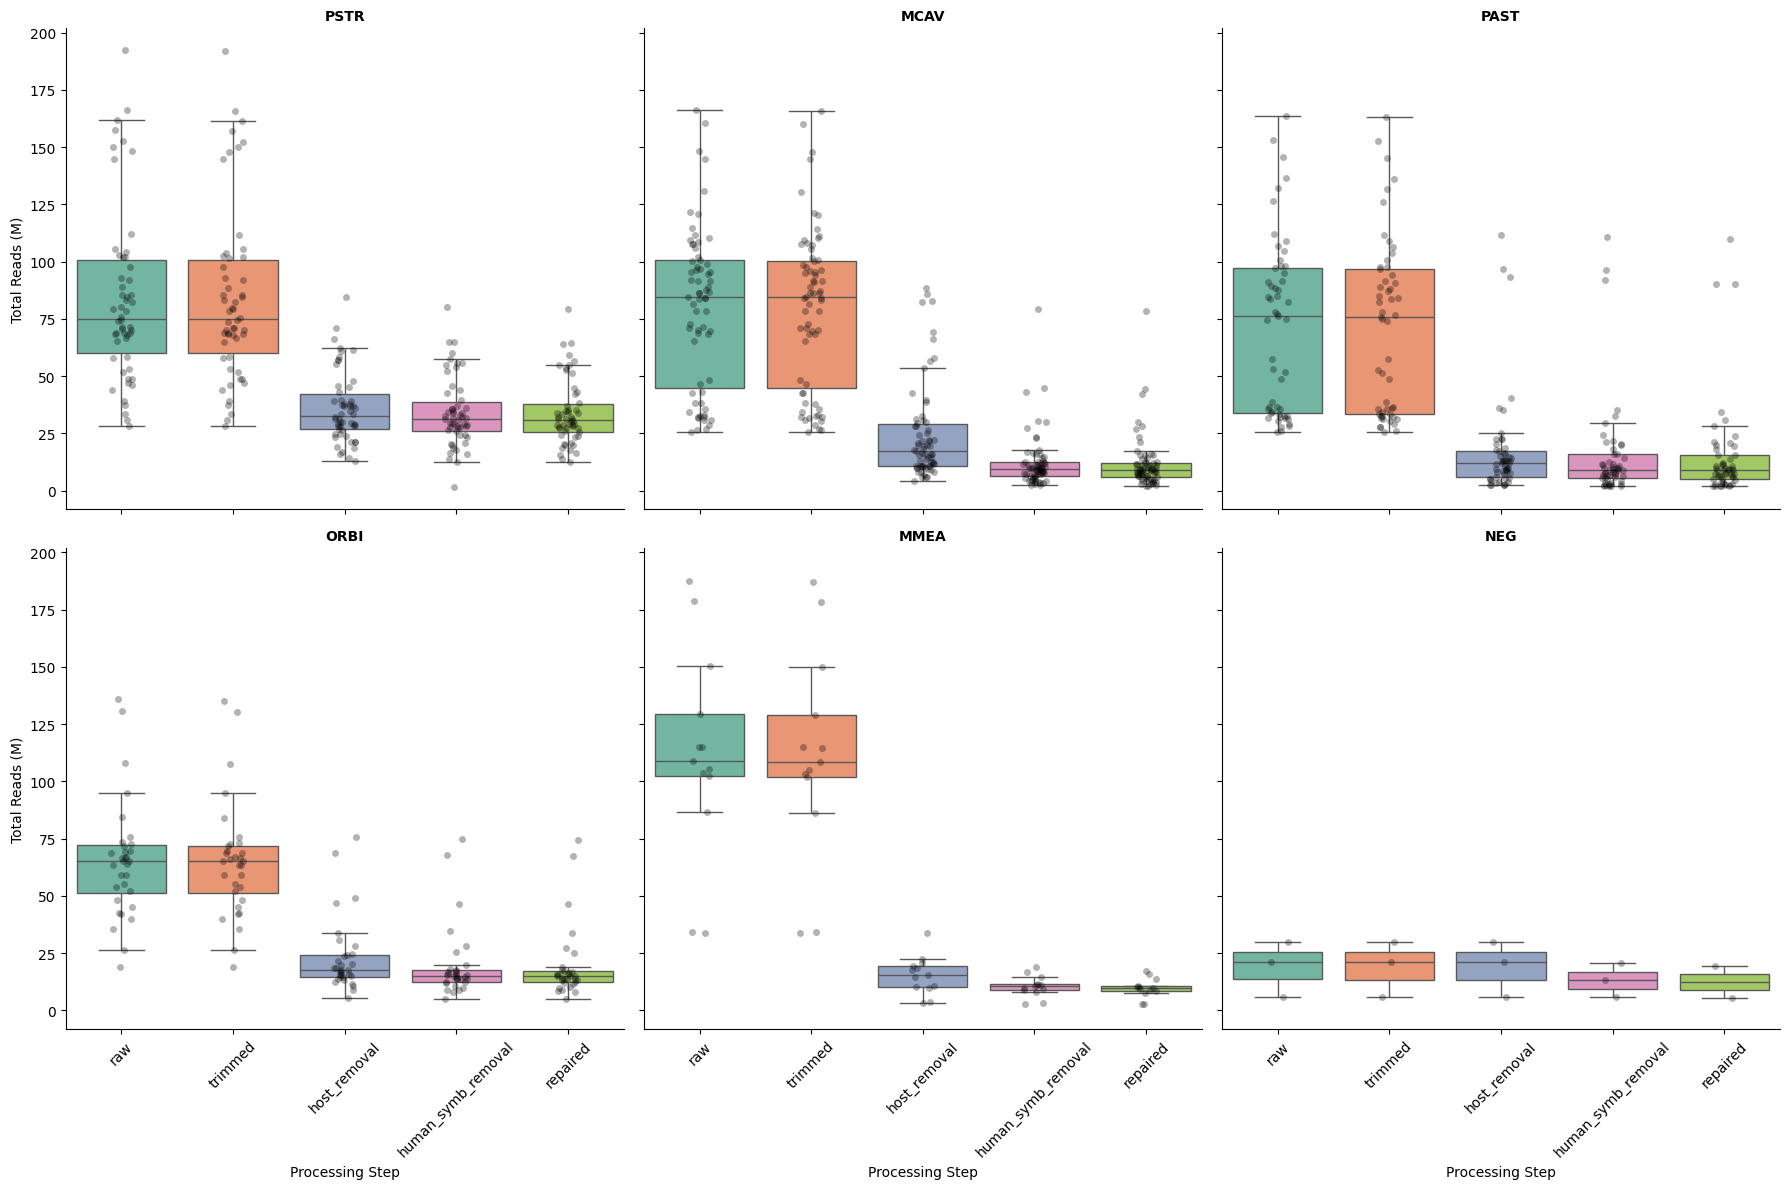

In [68]:
# help from gemini cuz havent used python in a while
plot_df['Step'] = pd.Categorical(plot_df['Step'], categories=steps, ordered=True)

plt.figure(figsize=(15, 8))

# Using catplot to create a grid of plots (one per species)
g = sns.catplot(data=plot_df, x='Step', y='read_count_M', col='Species', kind='box', 
    col_wrap=3,height=6,hue='Step', palette='Set2', legend=False,
                showfliers=False   # Points will be shown by stripplot instead
)
g.map_dataframe(sns.stripplot, x='Step', y='read_count_M', color='black', alpha=0.3, jitter=True)
g.set_axis_labels("Processing Step", "Total Reads (M)")
g.set_titles("{col_name}", weight='bold')
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=45)
plt.tight_layout()
plt.show()

In [69]:
# tragic
# PSTR mapped to host alot (CNAT) but is running into downstream issues

In [70]:
# percent loss 
# after host removal then symbiont removal
reads.head()

,sampleid,raw,trimmed,host_removal,human_symb_removal,repaired,Species,Transect,colony_id,Health_status,group
0,052022_BEL_CBC_T1_10_PSTR,68572842,68449647,28910191.0,28187436.0,27922584.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Margin,52022_PSTR_Diseased_Margin
1,052022_BEL_CBC_T1_11_PSTR,48741905,48660782,23319939.0,20372298.0,20064803.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Tissue,52022_PSTR_Diseased_Tissue
2,052022_BEL_CBC_T1_12_MCAV,166267321,165624856,53609962.0,16897860.0,15467061.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Margin,52022_MCAV_Diseased_Margin
3,052022_BEL_CBC_T1_13_MCAV,86263796,86076666,82372839.0,8467927.0,6251710.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Tissue,52022_MCAV_Diseased_Tissue
4,052022_BEL_CBC_T1_1_PAST,85047990,84808864,8979005.0,5410748.0,5151756.0,PAST,CBC30N,T1_2_PAST,Healthy,52022_PAST_Healthy


In [71]:
reads['pct_host_aligned']=((reads['trimmed']-reads['host_removal']) / reads['trimmed'])*100

#### Host Alignment

Text(0.5, 0, 'Species')

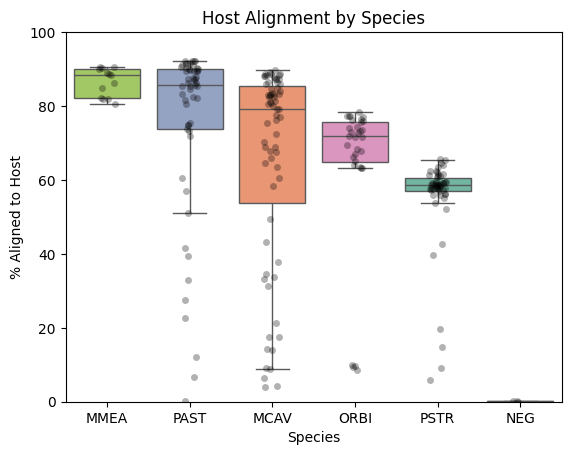

In [72]:
order = reads.groupby('Species')['pct_host_aligned'].median().sort_values(ascending=False).index
sns.boxplot(data=reads, x='Species', y='pct_host_aligned',
            order = order,
            palette = 'Set2',hue = 'Species',
            showfliers=False   # Points will be shown by stripplot instead
)
sns.stripplot(data=reads, x='Species', y='pct_host_aligned', color='black', 
    alpha=0.3, 
    jitter=True
)
plt.title('Host Alignment by Species')
plt.ylabel('% Aligned to Host')
plt.ylim(0, 100)
plt.xlabel('Species')

In [73]:
reads.head()

,sampleid,raw,trimmed,host_removal,human_symb_removal,repaired,Species,Transect,colony_id,Health_status,group,pct_host_aligned
0,052022_BEL_CBC_T1_10_PSTR,68572842,68449647,28910191.0,28187436.0,27922584.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Margin,52022_PSTR_Diseased_Margin,57.764295
1,052022_BEL_CBC_T1_11_PSTR,48741905,48660782,23319939.0,20372298.0,20064803.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Tissue,52022_PSTR_Diseased_Tissue,52.076522
2,052022_BEL_CBC_T1_12_MCAV,166267321,165624856,53609962.0,16897860.0,15467061.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Margin,52022_MCAV_Diseased_Margin,67.631693
3,052022_BEL_CBC_T1_13_MCAV,86263796,86076666,82372839.0,8467927.0,6251710.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Tissue,52022_MCAV_Diseased_Tissue,4.302940
4,052022_BEL_CBC_T1_1_PAST,85047990,84808864,8979005.0,5410748.0,5151756.0,PAST,CBC30N,T1_2_PAST,Healthy,52022_PAST_Healthy,89.412657


In [74]:
reads.describe()
6.030707e+06	

6030707.0

In [75]:
# without negatives
reads_noneg=reads.loc[reads['Species'] != "NEG"]
reads_noneg.describe()

,raw,trimmed,host_removal,human_symb_removal,repaired,pct_host_aligned
count,2.190000e+02,2.190000e+02,2.190000e+02,2.190000e+02,2.190000e+02,219.000000
mean,7.868027e+07,7.848760e+07,2.503620e+07,1.943964e+07,1.907045e+07,66.180981
std,3.714249e+07,3.704023e+07,2.008501e+07,1.817863e+07,1.788341e+07,23.439308
min,1.897959e+07,1.894102e+07,2.292432e+06,1.539118e+06,1.861295e+06,0.142064
25%,4.752295e+07,4.745832e+07,1.156374e+07,8.072396e+06,7.645714e+06,58.208116
50%,7.573788e+07,7.562760e+07,1.867795e+07,1.271388e+07,1.260712e+07,71.968560
75%,1.005758e+08,1.003759e+08,3.123427e+07,2.748756e+07,2.712538e+07,85.125044
max,1.923018e+08,1.919380e+08,1.116404e+08,1.108031e+08,1.100230e+08,92.103855


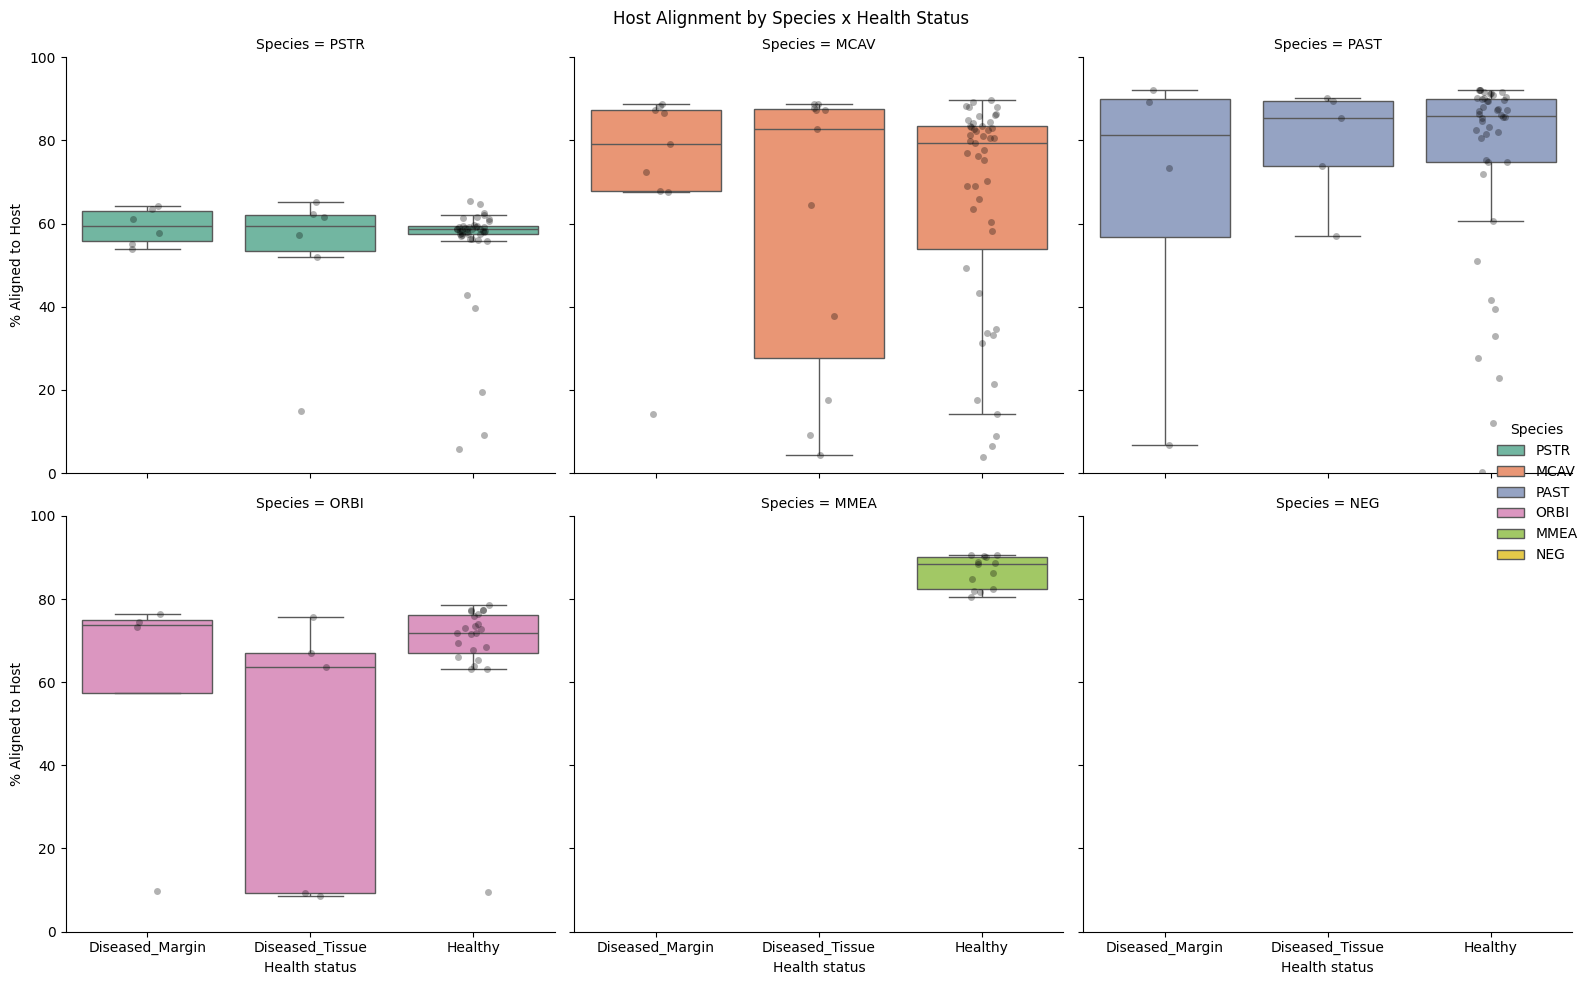

In [76]:
sp=sns.catplot(data=reads, x='Health_status', y='pct_host_aligned',col = 'Species',
            kind = 'box',
            # order = order,
            col_wrap = 3,
            palette = 'Set2',hue = 'Species',
            showfliers=False
)
sp.map_dataframe(sns.stripplot,x='Health_status', y='pct_host_aligned', color='black',
                                 # order = order,
                 alpha=0.3, jitter=True
)
sp.fig.suptitle('Host Alignment by Species x Health Status')
sp.set_axis_labels('Health status','% Aligned to Host')
sp.set(ylim=(0, 100))
plt.tight_layout()
plt.show()

#### Overall Read Counts x Spp

In [77]:
reads.head()

,sampleid,raw,trimmed,host_removal,human_symb_removal,repaired,Species,Transect,colony_id,Health_status,group,pct_host_aligned
0,052022_BEL_CBC_T1_10_PSTR,68572842,68449647,28910191.0,28187436.0,27922584.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Margin,52022_PSTR_Diseased_Margin,57.764295
1,052022_BEL_CBC_T1_11_PSTR,48741905,48660782,23319939.0,20372298.0,20064803.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Tissue,52022_PSTR_Diseased_Tissue,52.076522
2,052022_BEL_CBC_T1_12_MCAV,166267321,165624856,53609962.0,16897860.0,15467061.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Margin,52022_MCAV_Diseased_Margin,67.631693
3,052022_BEL_CBC_T1_13_MCAV,86263796,86076666,82372839.0,8467927.0,6251710.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Tissue,52022_MCAV_Diseased_Tissue,4.302940
4,052022_BEL_CBC_T1_1_PAST,85047990,84808864,8979005.0,5410748.0,5151756.0,PAST,CBC30N,T1_2_PAST,Healthy,52022_PAST_Healthy,89.412657


Text(0.5, 0, 'Species')

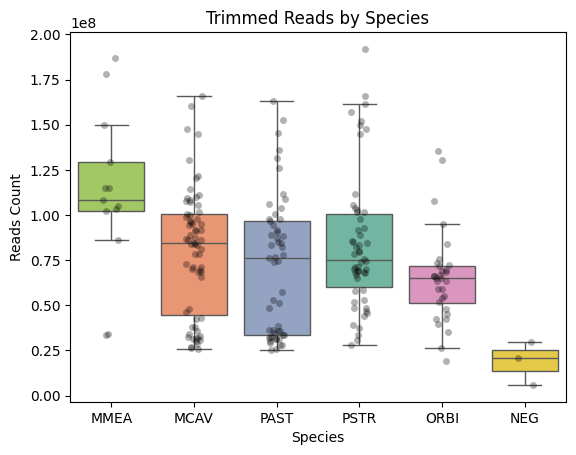

In [78]:
order = reads.groupby('Species')['trimmed'].median().sort_values(ascending=False).index
sns.boxplot(data=reads, x='Species', y='trimmed',
            order = order,
            palette = 'Set2',hue = 'Species',
            showfliers=False   # Points will be shown by stripplot instead
)
sns.stripplot(data=reads, x='Species', y='trimmed', color='black', 
    alpha=0.3, 
    jitter=True
)
plt.title('Trimmed Reads by Species')
plt.ylabel('Reads Count')
plt.xlabel('Species')
# 200,000,000
# 25,000,000

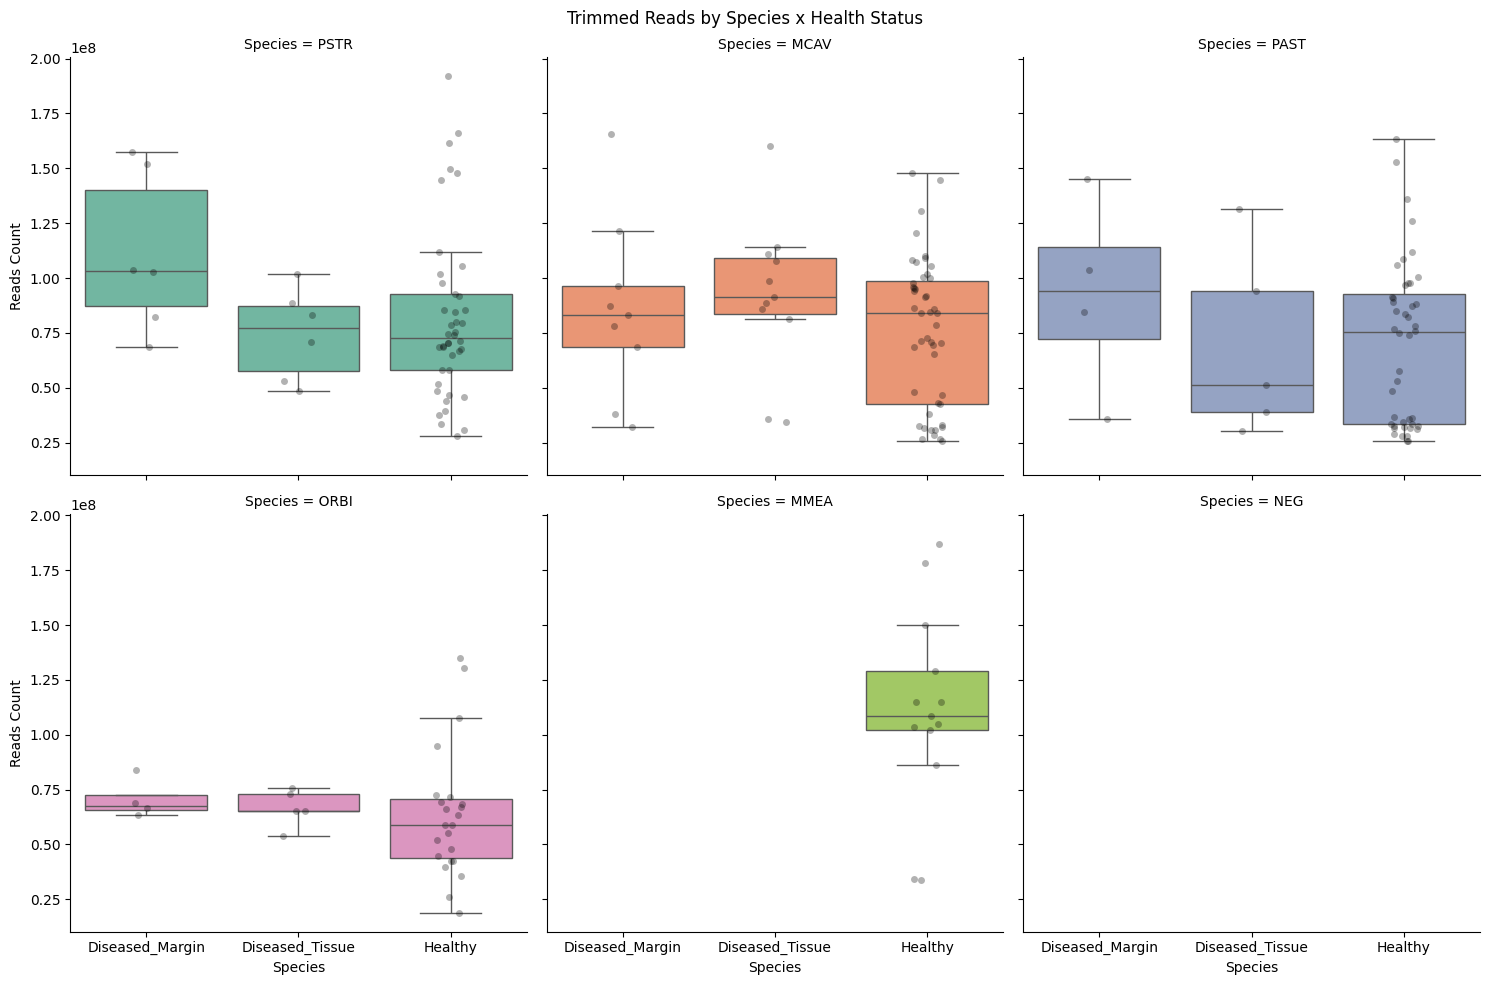

In [79]:
sp=sns.catplot(data=reads, x='Health_status', y='trimmed',col = 'Species',
            kind = 'box',
            palette = 'Set2',hue = 'Species',
            col_wrap = 3,
            showfliers=False,
            legend = False
)
sp.map_dataframe(sns.stripplot,x='Health_status', y='trimmed', color='black',
                 alpha=0.3, jitter=True
)
sp.fig.suptitle('Trimmed Reads by Species x Health Status')
sp.set_axis_labels('Species','Reads Count')
plt.tight_layout()
plt.show()

In [80]:
reads.head()

,sampleid,raw,trimmed,host_removal,human_symb_removal,repaired,Species,Transect,colony_id,Health_status,group,pct_host_aligned
0,052022_BEL_CBC_T1_10_PSTR,68572842,68449647,28910191.0,28187436.0,27922584.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Margin,52022_PSTR_Diseased_Margin,57.764295
1,052022_BEL_CBC_T1_11_PSTR,48741905,48660782,23319939.0,20372298.0,20064803.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Tissue,52022_PSTR_Diseased_Tissue,52.076522
2,052022_BEL_CBC_T1_12_MCAV,166267321,165624856,53609962.0,16897860.0,15467061.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Margin,52022_MCAV_Diseased_Margin,67.631693
3,052022_BEL_CBC_T1_13_MCAV,86263796,86076666,82372839.0,8467927.0,6251710.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Tissue,52022_MCAV_Diseased_Tissue,4.302940
4,052022_BEL_CBC_T1_1_PAST,85047990,84808864,8979005.0,5410748.0,5151756.0,PAST,CBC30N,T1_2_PAST,Healthy,52022_PAST_Healthy,89.412657


Text(0.5, 0, 'Species')

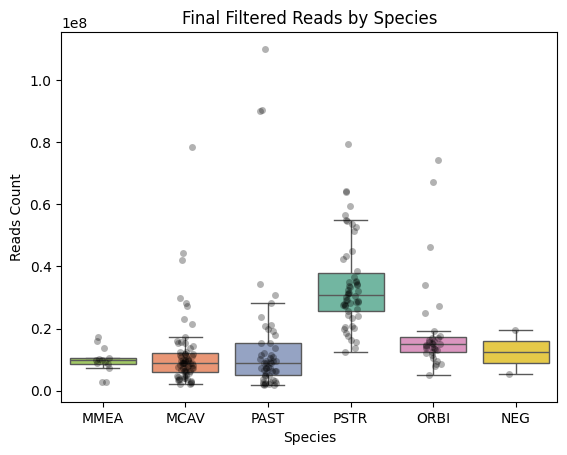

In [81]:
sns.boxplot(data=reads, x='Species', y='repaired',
            order = order,
            palette = 'Set2',hue = 'Species',
            showfliers=False
)
sns.stripplot(data=reads, x='Species', y='repaired', color='black', 
    alpha=0.3, 
    jitter=True
)
plt.title('Final Filtered Reads by Species')
plt.ylabel('Reads Count')
plt.xlabel('Species')

In [82]:
78,898,318
60,000,000

(60, 0, 0)

In [83]:
reads['human_symb_removal'].describe()

count    2.220000e+02
mean     1.935495e+07
std      1.808349e+07
min      1.539118e+06
25%      8.069798e+06
50%      1.276125e+07
75%      2.719746e+07
max      1.108031e+08
Name: human_symb_removal, dtype: float64

In [84]:
reads['host_removal'].describe()

count    2.220000e+02
mean     2.495386e+07
std      1.999390e+07
min      2.292432e+06
25%      1.152403e+07
50%      1.868631e+07
75%      3.109380e+07
max      1.116404e+08
Name: host_removal, dtype: float64

In [85]:
# plot symbiont type matching over


In [86]:
multiqc_df.head()

,Sample,total_reads,Human counts,Human percentage,Symbiont1 counts,Symbiont1 percentage,Symbiont2 counts,Symbiont2 percentage,Symbiont3 counts,Symbiont3 percentage,...,Symbiont9 counts,Symbiont9 percentage,Symbiont10 counts,Symbiont10 percentage,Symbiont11 counts,Symbiont11 percentage,No hits counts,No hits percentage,sampleid,human_removal_counts
0,052022_BEL_CBC_T1_35_OANN_host_removed_R1_screen,20263133,391362.0,1.93,511515.0,2.52,610476.0,3.02,2056638.0,10.15,...,621394.0,3.06,1156392.0,5.70,2282113.0,11.27,11829617,58.38,052022_BEL_CBC_T1_35_OANN,19871771.0
1,052022_BEL_CBC_T1_35_OANN_host_removed_R2_screen,20263133,427477.0,2.11,565874.0,2.79,664377.0,3.28,2096339.0,10.35,...,677322.0,3.34,1210016.0,5.96,2318793.0,11.44,11825564,58.36,052022_BEL_CBC_T1_35_OANN,19835656.0
2,052022_BEL_CBC_T1_41_OANN_host_removed_R1_screen,11347352,219522.0,1.93,491968.0,4.34,272184.0,2.40,600734.0,5.29,...,282369.0,2.49,403722.0,3.55,674763.0,5.94,8906536,78.49,052022_BEL_CBC_T1_41_OANN,11127830.0
3,052022_BEL_CBC_T1_41_OANN_host_removed_R2_screen,11347352,242695.0,2.14,527117.0,4.64,308654.0,2.72,634552.0,5.59,...,319546.0,2.82,440661.0,3.88,708462.0,6.24,8884976,78.30,052022_BEL_CBC_T1_41_OANN,11104657.0
4,052022_BEL_CBC_T1_63_OANN_host_removed_R1_screen,21522792,336297.0,1.57,307063.0,1.43,383069.0,1.78,967873.0,4.49,...,384071.0,1.78,560938.0,2.61,1067664.0,4.96,18171693,84.43,052022_BEL_CBC_T1_63_OANN,21186495.0


In [87]:
multiqc_df['Human percentage'].describe()

count    444.000000
mean       2.500315
std        3.972388
min        0.260000
25%        1.257500
50%        2.120000
75%        2.822500
max       56.260000
Name: Human percentage, dtype: float64

In [90]:
max_row = multiqc_df.loc[multiqc_df['Human percentage'].idxmax()]
max_row

Sample                   Negative_extract_11-2-24_final_host_removed_R2...
total_reads                                                       29875291
Human counts                                                    16808311.0
Human percentage                                                     56.26
Symbiont1 counts                                                  452221.0
Symbiont1 percentage                                                  1.51
Symbiont2 counts                                                  423846.0
Symbiont2 percentage                                                  1.42
Symbiont3 counts                                                  504408.0
Symbiont3 percentage                                                  1.68
Symbiont4 counts                                                  469759.0
Symbiont4 percentage                                                  1.57
Symbiont5 counts                                                  521936.0
Symbiont5 percentage     

In [97]:
# ok without negatives 
clean_multiqc_df=multiqc_df.loc[~multiqc_df['Sample'].str.contains('Neg', case=False, na=False)]
clean_multiqc_df['Human percentage'].describe()

count    438.000000
mean       2.239475
std        1.644665
min        0.260000
25%        1.252500
50%        2.105000
75%        2.810000
max       20.610000
Name: Human percentage, dtype: float64

In [99]:
clean_multiqc_df.loc[clean_multiqc_df['Human percentage'].idxmax()]

Sample                   062019_BEL_CBC_T3_7_PAST_host_removed_R2_screen
total_reads                                                     14546111
Human counts                                                   2999046.0
Human percentage                                                   20.61
Symbiont1 counts                                                331833.0
Symbiont1 percentage                                                2.27
Symbiont2 counts                                                361982.0
Symbiont2 percentage                                                2.49
Symbiont3 counts                                                912635.0
Symbiont3 percentage                                                6.28
Symbiont4 counts                                                786659.0
Symbiont4 percentage                                                 5.4
Symbiont5 counts                                                396819.0
Symbiont5 percentage                               

In [103]:
# Filter and display samples where Human percentage is > 5%
high_host_samples = clean_multiqc_df.loc[clean_multiqc_df['Human percentage'] > 5,]

# Sort from highest to lowest
high_host_samples.sort_values(by='Human percentage', ascending=False)

,Sample,total_reads,Human counts,Human percentage,Symbiont1 counts,Symbiont1 percentage,Symbiont2 counts,Symbiont2 percentage,Symbiont3 counts,Symbiont3 percentage,...,Symbiont9 counts,Symbiont9 percentage,Symbiont10 counts,Symbiont10 percentage,Symbiont11 counts,Symbiont11 percentage,No hits counts,No hits percentage,sampleid,human_removal_counts
347,062019_BEL_CBC_T3_7_PAST_host_removed_R2_screen,14546111,2999046.0,20.61,331833.0,2.27,361982.0,2.49,912635.0,6.28,...,393194.0,2.70,519185.0,3.56,1100728.0,7.57,9876809,67.90,062019_BEL_CBC_T3_7_PAST,11547065.0
346,062019_BEL_CBC_T3_7_PAST_host_removed_R1_screen,14546111,2967338.0,20.39,280360.0,1.92,311392.0,2.14,868742.0,5.97,...,340631.0,2.34,467153.0,3.21,1059676.0,7.28,9905901,68.10,062019_BEL_CBC_T3_7_PAST,11578773.0
477,062019_BEL_CBC_T3_6_MCAV_host_removed_R2_screen,10944791,687606.0,6.29,373270.0,3.41,366408.0,3.34,318252.0,2.91,...,888220.0,8.12,262422.0,2.40,308847.0,2.83,7353805,67.19,062019_BEL_CBC_T3_6_MCAV,10257185.0
476,062019_BEL_CBC_T3_6_MCAV_host_removed_R1_screen,10944791,682095.0,6.23,369277.0,3.37,363413.0,3.32,311940.0,2.86,...,890342.0,8.14,255791.0,2.33,302421.0,2.76,7346143,67.12,062019_BEL_CBC_T3_6_MCAV,10262696.0
343,062019_BEL_CBC_T3_31_PAST_host_removed_R2_screen,17144325,986041.0,5.76,517992.0,3.02,506873.0,2.95,1176618.0,6.86,...,535784.0,3.12,697599.0,4.06,1427003.0,8.33,14092635,82.20,062019_BEL_CBC_T3_31_PAST,16158284.0
293,052022_BEL_CBC_T2_60_PAST_host_removed_R2_screen,96842625,5222061.0,5.38,5351355.0,5.52,5385429.0,5.56,5688193.0,5.87,...,5628150.0,5.80,5665733.0,5.85,5734791.0,5.92,90741539,93.70,052022_BEL_CBC_T2_60_PAST,91620564.0
479,062019_BEL_CBC_T3_8_MCAV_host_removed_R2_screen,24170294,1262342.0,5.23,987046.0,4.08,908463.0,3.76,741669.0,3.07,...,2868309.0,11.87,615552.0,2.54,723453.0,3.00,11986048,49.59,062019_BEL_CBC_T3_8_MCAV,22907952.0
478,062019_BEL_CBC_T3_8_MCAV_host_removed_R1_screen,24170294,1226727.0,5.08,961525.0,3.97,881999.0,3.65,705932.0,2.92,...,2866842.0,11.85,577892.0,2.38,686768.0,2.84,11964295,49.50,062019_BEL_CBC_T3_8_MCAV,22943567.0
441,062019_BEL_CBC_T1_22_MCAV_host_removed_R2_screen,88607931,4485422.0,5.06,4255538.0,4.80,3723545.0,4.20,2705429.0,3.05,...,13535013.0,15.28,2315791.0,2.61,2709170.0,3.05,29869733,33.71,062019_BEL_CBC_T1_22_MCAV,84122509.0
440,062019_BEL_CBC_T1_22_MCAV_host_removed_R1_screen,88607931,4435390.0,5.01,4224197.0,4.77,3687415.0,4.16,2654758.0,2.99,...,13573487.0,15.32,2263612.0,2.55,2657169.0,2.99,29754543,33.58,062019_BEL_CBC_T1_22_MCAV,84172541.0
